In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, mean_absolute_error
ohe = OneHotEncoder()

In [5]:
df = pd.read_csv("datasets/diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [6]:
df.drop(columns=['x','y','z','table','depth'], inplace=True)

In [7]:
df.head()

,carat,cut,color,clarity,price
0,0.23,Ideal,E,SI2,326
1,0.21,Premium,E,SI1,326
2,0.23,Good,E,VS1,327
3,0.29,Premium,I,VS2,334
4,0.31,Good,J,SI2,335


In [8]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
price      0
dtype: int64

In [9]:
df.shape

(53940, 5)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   price    53940 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 2.1+ MB


In [11]:
# Define custom orderings
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Create encoder with specified categories
encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])

# Fit and transform
df_encoded = df.copy()
df_encoded[['cut', 'color', 'clarity']] = encoder.fit_transform(df[['cut', 'color', 'clarity']])

# Show encoded data
print(df_encoded)

       carat  cut  color  clarity  price
0       0.23  4.0    5.0      1.0    326
1       0.21  3.0    5.0      2.0    326
2       0.23  1.0    5.0      4.0    327
3       0.29  3.0    1.0      3.0    334
4       0.31  1.0    0.0      1.0    335
...      ...  ...    ...      ...    ...
53935   0.72  4.0    6.0      2.0   2757
53936   0.72  1.0    6.0      2.0   2757
53937   0.70  2.0    6.0      2.0   2757
53938   0.86  3.0    2.0      1.0   2757
53939   0.75  4.0    6.0      1.0   2757

[53940 rows x 5 columns]


In [12]:
x = df_encoded.drop(columns=['price'])
y = df_encoded['price']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(43152, 4)
(10788, 4)


In [14]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [15]:
y_pred = model.predict(x_test)

In [16]:
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
print(f"R2 score is {r2}")
print(f"Mean absolute error is {mae}")

R2 score is 0.9030563214406131
Mean absolute error is 855.7062135327616


## for residual plot


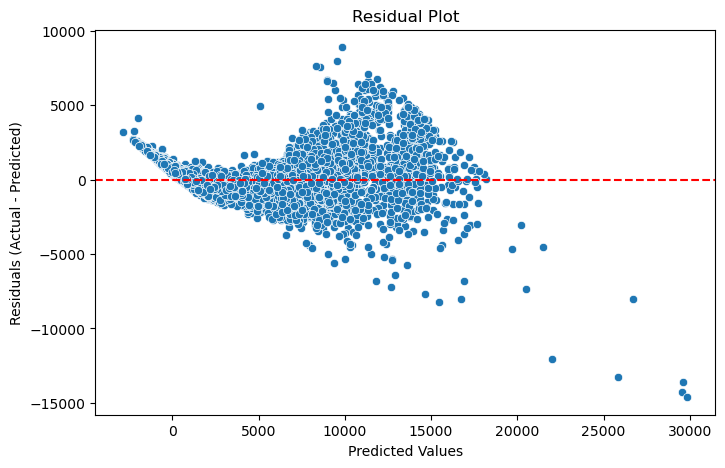

In [17]:
import seaborn as sns

# Residuals
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

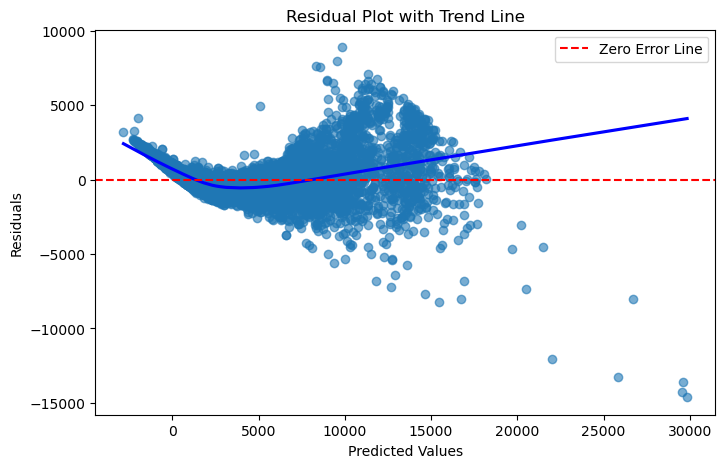

In [18]:
plt.figure(figsize=(8,5))
sns.regplot(x=y_pred, y=residuals, scatter=True, lowess=True, 
            line_kws={"color":"blue"}, scatter_kws={"alpha":0.6})
plt.axhline(0, color='red', linestyle='--', label='Zero Error Line')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot with Trend Line")
plt.legend()
plt.show()
